# Prompt 1B - Final Regression V2 Data

## 1. Objective

This notebook reports the saved Prompt 1B results. It does not rebuild data, open Raw files, change membership, or run a model.

In [1]:
from pathlib import Path
import json
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

# Find the Regression V2 root from the notebook working directory.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
REPORT_DIR = PROJECT_ROOT / 'outputs' / 'reports'
DATA_DIR = PROJECT_ROOT / 'outputs' / 'data'

def load_report(name):
    return json.loads((REPORT_DIR / name).read_text(encoding='utf-8'))

dedup = load_report('prompt1b_deduplication_report.json')
conflict = load_report('prompt1b_conflict_report.json')
legacy = load_report('prompt1b_legacy_exclusion_report.json')
roles = load_report('feature_roles.json')
split = load_report('split_manifest.json')
build = load_report('data_build_report.json')
pd.DataFrame([{'saved_build_status': build['status'], 'raw_access_count': build['raw_access_count'], 'model_fit_count': build['model_fit_count']}])

,saved_build_status,raw_access_count,model_fit_count
0,PASS,0,0


## 2. Prompt 1A handoff

Prompt 1A supplied 112 validated ZSTD Parquet partitions. Prompt 1B used only this saved staging population.

In [2]:
handoff = build['prompt1a_handoff']
pd.DataFrame([{
    'status': handoff['status'],
    'partitions': handoff['partition_count'],
    'rows': handoff['staged_rows'],
    'storage_bytes': handoff['staging_bytes'],
    'all_hashes_match': handoff['all_hashes_match'],
    'all_partitions_reloaded': handoff['all_partitions_reloaded'],
}])

,status,partitions,rows,storage_bytes,all_hashes_match,all_partitions_reloaded
0,PASS,112,6471630,142659308,True,True


## 3. Eligible population

The table follows the fixed order of population changes. Membership was not changed after distribution review.

In [3]:
population = build['population']
population_table = pd.DataFrame([
    {'step': 'Prompt 1A staged', 'rows': population['staged']},
    {'step': 'After exact deduplication', 'rows': population['deduplicated']},
    {'step': 'After conflict exclusion', 'rows': population['deduplicated'] - population['conflict_excluded']},
    {'step': 'After Legacy exclusion', 'rows': population['eligible_after_exclusions']},
    {'step': 'Deterministic selected population', 'rows': population['selected']},
])
population_table

,step,rows
0,Prompt 1A staged,6471630
1,After exact deduplication,6465188
2,After conflict exclusion,6408513
3,After Legacy exclusion,5912763
4,Deterministic selected population,575000


## 4. Global exact deduplication

Exact grouping compared all 30 saved staging fields. SHA-256 was stored for audit, but a hash alone did not decide equality.

In [4]:
pd.DataFrame([{
    'rows_before': dedup['rows_before_deduplication'],
    'duplicate_groups': dedup['exact_duplicate_groups'],
    'copies_removed': dedup['duplicate_copies_removed'],
    'rows_after': dedup['rows_after_exact_deduplication'],
    'collision_safe_exact_check': True,
}])

,rows_before,duplicate_groups,copies_removed,rows_after,collision_safe_exact_check
0,6471630,5790,6442,6465188,True


## 5. Contradictory target groups

The target was excluded from `row_hash`, while `action_taken_code` remained. Every row in each multi-target identity group was removed.

In [5]:
pd.DataFrame([{
    'contradictory_groups': conflict['contradictory_group_count'],
    'affected_rows': conflict['affected_exact_deduplicated_rows'],
    'excluded_rows': conflict['excluded_row_count'],
    'full_group_exclusion': conflict['full_group_exclusion'],
}])

,contradictory_groups,affected_rows,excluded_rows,full_group_exclusion
0,27691,56675,56675,True


## 6. Legacy exclusion

The preferred old 500,000-row sample was used. All 28 reliable shared base fields formed the key. Numeric values used fixed decimal canonicalization only to remove tiny CSV round-trip noise.

In [6]:
pd.DataFrame([{
    'legacy_source_rows': legacy['source_rows'],
    'unique_legacy_keys': legacy['source_unique_normalized_keys'],
    'matched_legacy_keys': legacy['matched_legacy_keys'],
    'unmatched_legacy_keys': legacy['unmatched_legacy_keys'],
    'v2_rows_excluded': legacy['v2_rows_excluded_after_conflict_removal'],
    'identity_collapse_from_float_canonicalization': legacy['numeric_canonicalization_identity_collapse'],
}])

,legacy_source_rows,unique_legacy_keys,matched_legacy_keys,unmatched_legacy_keys,v2_rows_excluded,identity_collapse_from_float_canonicalization
0,500000,499736,499736,0,495750,0


## 7. Deterministic candidate selection

The build ranked `SHA-256('regression_v2_seed_42' + row_hash)` and kept exactly the smallest 575,000 values. The target did not enter this score.

## 8. Development/IID split

Duplicate-safe target deciles and random state 42 created the fixed 500,000 Development and 75,000 IID memberships.

## 9. Development Train/Validation split

The same rule split Development into 400,000 Train and 100,000 Validation rows.

,set,rows
0,Development Train,400000
1,Development Validation,100000
2,IID Holdout,75000


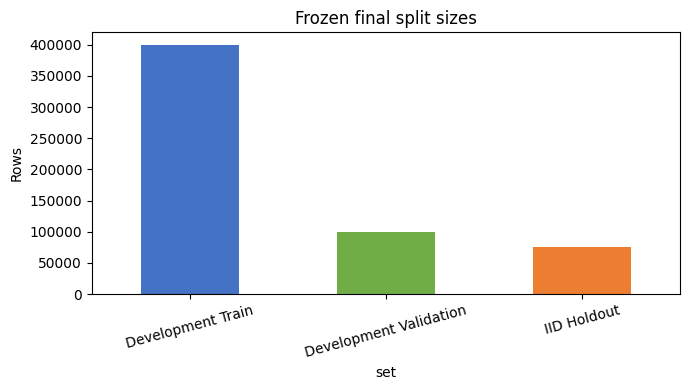

In [7]:
split_counts = pd.DataFrame([
    {'set': 'Development Train', 'rows': split['train_rows']},
    {'set': 'Development Validation', 'rows': split['validation_rows']},
    {'set': 'IID Holdout', 'rows': split['iid_rows']},
])
display(split_counts)
ax = split_counts.plot.bar(x='set', y='rows', legend=False, figsize=(7, 4), color=['#4472C4', '#70AD47', '#ED7D31'])
ax.set_title('Frozen final split sizes')
ax.set_ylabel('Rows')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 10. Feature engineering

Exactly 16 legacy formulas were applied after final membership selection. The table reports saved null and non-finite checks.

In [8]:
feature_checks = pd.DataFrame([{'feature': name, **values} for name, values in build['engineered_feature_checks'].items()])
feature_checks

,feature,status,nulls,nonfinite
0,log1p_applicant_income,PASS,0,0.0
1,log1p_population,PASS,0,0.0
2,log1p_hud_median_family_income,PASS,0,0.0
3,log1p_owner_occupied_units,PASS,0,0.0
4,log1p_1_to_4_family_units,PASS,0,0.0
5,applicant_income_to_area_income,PASS,0,0.0
6,tract_income_ratio,PASS,0,0.0
7,owner_occupied_unit_ratio,PASS,0,0.0
8,family_units_per_1000_people,PASS,0,0.0
9,owner_occupied_units_per_1000_people,PASS,0,0.0


## 11. Feature contracts

One shared feature superset supports three controlled contracts. Default contracts exclude the target, audit fields, and explicit sensitive fields.

In [9]:
pd.DataFrame([
    {'contract': name, 'feature_count': len(columns), 'contains_target': 'loan_amount_000s' in columns, 'contains_respondent_id': 'respondent_id' in columns}
    for name, columns in roles['contracts'].items()
])

,contract,feature_count,contains_target,contains_respondent_id
0,main_without_sensitive_without_lender,35,False,False
1,main_without_sensitive_with_lender,36,False,True
2,diagnostic_with_sensitive,43,False,True


## 12. Target-distribution comparison

These summaries describe the frozen splits. They were not used to change membership.

,count,mean,standard_deviation,minimum,median,p90,p95,p99,maximum
development_train,400000,249.705433,282.223472,1.0,202.0,438.0,592.0,1080.0,102000.0
development_validation,100000,248.83624,227.191069,1.0,202.0,438.0,589.0,1073.02,9750.0
iid_holdout,75000,249.544413,237.266579,1.0,202.0,438.0,592.0,1070.01,14400.0


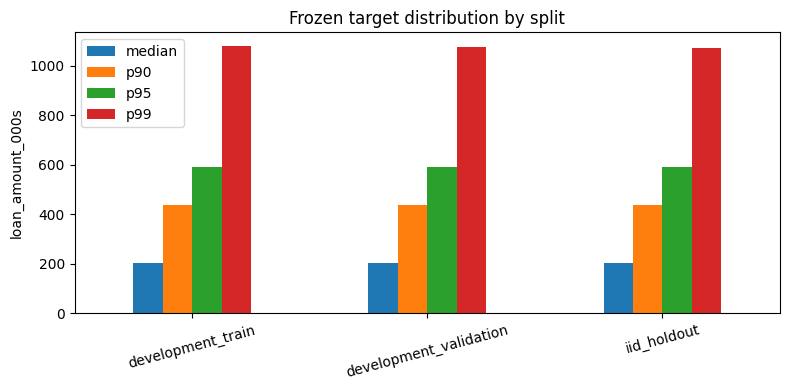

In [10]:
distribution = pd.DataFrame(split['target_distributions']).T
summary_columns = ['count', 'mean', 'standard_deviation', 'minimum', 'median', 'p90', 'p95', 'p99', 'maximum']
display(distribution[summary_columns])
ax = distribution[['median', 'p90', 'p95', 'p99']].plot.bar(figsize=(8, 4))
ax.set_title('Frozen target distribution by split')
ax.set_ylabel('loan_amount_000s')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 13. Final schemas and storage

IID targets are physically separate. This notebook reads only Parquet metadata and does not display any IID target value.

In [11]:
storage_rows = []
for name, filename in [('Development', 'development.parquet'), ('IID features', 'iid_holdout_features.parquet'), ('IID targets', 'iid_holdout_targets.parquet')]:
    parquet = pq.ParquetFile(DATA_DIR / filename)
    storage_rows.append({
        'artifact': name, 'rows': parquet.metadata.num_rows,
        'columns': len(parquet.schema_arrow.names),
        'first_columns': ', '.join(parquet.schema_arrow.names[:4]),
        'compression': parquet.metadata.row_group(0).column(0).compression,
        'storage_bytes': (DATA_DIR / filename).stat().st_size,
    })
pd.DataFrame(storage_rows)

,artifact,rows,columns,first_columns,compression,storage_bytes
0,Development,500000,49,"respondent_id, agency_name, loan_type_name, pr...",ZSTD,64106244
1,IID features,75000,47,"respondent_id, agency_name, loan_type_name, pr...",ZSTD,9716038
2,IID targets,75000,2,"row_hash, loan_amount_000s",ZSTD,2759420


## 14. Verification

The saved build passed row-count, schema, ZSTD reload, feature, and ordered IID key checks. Independent review and final closure follow this notebook execution.

In [12]:
pd.DataFrame([{
    'build_status': build['status'],
    'development_rows': build['outputs']['development']['rows'],
    'iid_feature_rows': build['outputs']['iid_features']['rows'],
    'iid_target_rows': build['outputs']['iid_targets']['rows'],
    'engineered_infinity_count': build['engineered_infinity_count'],
    'unexpected_engineered_null_count': build['unexpected_engineered_null_count'],
    'raw_access_count': build['raw_access_count'],
    'model_fit_count': build['model_fit_count'],
}])

,build_status,development_rows,iid_feature_rows,iid_target_rows,engineered_infinity_count,unexpected_engineered_null_count,raw_access_count,model_fit_count
0,PASS,500000,75000,75000,0,0,0,0


## 15. Limitations

The IID set is independent of the known old regression sample, not of every possible external HMDA analysis. Target-decile stratification supports comparable target ranges but does not guarantee equal distributions. Sensitive columns are saved for controlled later diagnostics and must not enter default models.

## 16. Prompt 2 handoff

Prompt 2 may begin only after independent review, final verification, and `DATA_READY.json` all report PASS. This notebook does not start Prompt 2.